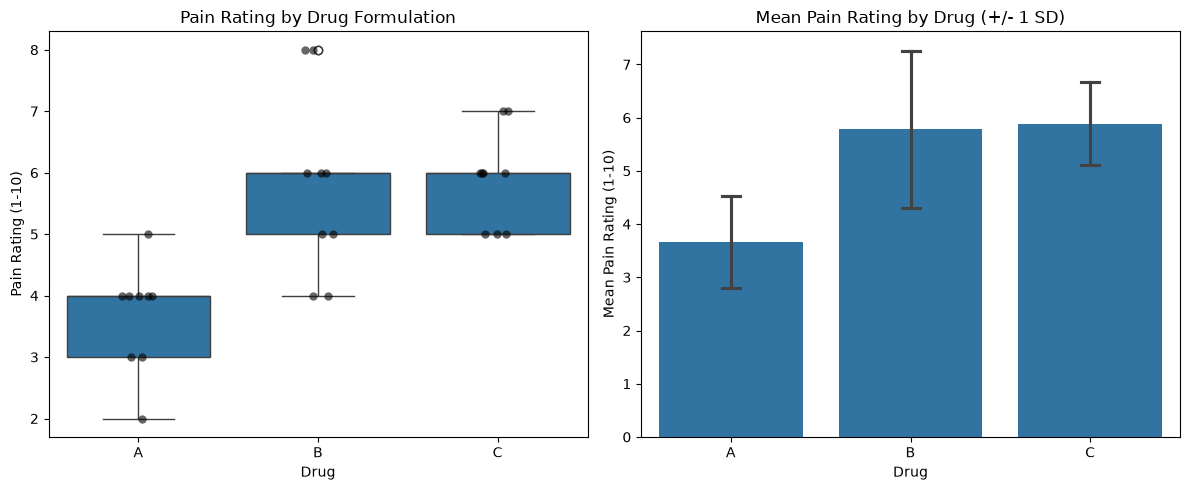

In [ ]:
#Q1

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.chdir('/Users/lior/DS6021/DS6021_F26/data')
#

df = pd.read_csv('Clinical_trial.csv')
order = ['A', 'B', 'C']

fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.boxplot(data=df, x='Drug', y='Pain_Rating', order=order, ax=axes[0])
sns.stripplot(data=df, x='Drug', y='Pain_Rating', order=order,
              color='black', alpha=0.6, size=6, ax=axes[0])
axes[0].set_title('Pain Rating by Drug Formulation')
axes[0].set_ylabel('Pain Rating (1-10)')

sns.barplot(data=df, x='Drug', y='Pain_Rating', order=order, ax=axes[1],
            errorbar='sd', capsize=0.1)
axes[1].set_title('Mean Pain Rating by Drug (+/- 1 SD)')
axes[1].set_ylabel('Mean Pain Rating (1-10)')

plt.tight_layout()
plt.show()

Drug A sits at a much lower point than Drugs B and C. Drugs B and C are similar to eachother and both have a pain rating between 5-6. It seems like Drug A is better when it comes to reducing pain compared to the other drugs.

In [4]:
#Q2

from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
#cleaned with claude
groups = [g['Pain_Rating'].values for _, g in df.groupby('Drug')]
levene_stat, levene_p = stats.levene(*groups)

model = ols('Pain_Rating ~ C(Drug)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
resid = model.resid
shapiro_stat, shapiro_p = stats.shapiro(resid)
tukey = pairwise_tukeyhsd(endog=df['Pain_Rating'], groups=df['Drug'], alpha=0.05)
print(anova_table)
print(tukey)


             sum_sq    df         F    PR(>F)
C(Drug)   28.222222   2.0  11.90625  0.000256
Residual  28.444444  24.0       NaN       NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     A      B   2.1111 0.0011  0.8295 3.3927   True
     A      C   2.2222 0.0006  0.9406 3.5038   True
     B      C   0.1111 0.9745 -1.1705 1.3927  False
---------------------------------------------------


In [ ]:
groups = [g['Pain_Rating'].values for _, g in df.groupby('Drug')]
levene_stat, levene_p = stats.levene(*groups)
print(f"Levene's test: stat = {levene_stat:.4f}, p = {levene_p:.4f}")

Levene's test: stat = 1.6667, p = 0.2100


In [7]:
model = ols('Pain_Rating ~ C(Drug)', data=df).fit()
resid = model.resid

shapiro_stat, shapiro_p = stats.shapiro(resid)
print(f"Shapiro-Wilk on residuals: stat = {shapiro_stat:.4f}, p = {shapiro_p:.4f}")

Shapiro-Wilk on residuals: stat = 0.9367, p = 0.1013


Q2
Does the type of specific drug someone takes make a difference in how much pain relief they get?

Null Hypotheses: All of the drugs produce the same results
Alternative hypothesis: One of the drugs produces a different result than the rest

I used a Levenes test to see the variability across groups and it came back with p=0.21 meaning that my assumption that the spreads are different holds. According to the Shapiro Wilk test, the results also seems normal and my assumption still holds.

I also ran a one way ANOVA comparing the averae pain ratings which was F=11.91 and p= 0.00026 which means that its highly unlikely that there will be a big difference between the three groups by chance. So, the null hypothesis is rejected and the type of drug does make a difference in reported pain. 

In order to determine which drug is the best, I made a chart comparing each drug to one another. Drug A's result shows that its very obvious that its the drug that produces a lot less pain ratings than both of the other drugs. Drug A and B perform about the same as eachother. It seems ike drug A would be the most effective when it comes to reducing migraine pain within 30 mins.

Q3
If I wanted to look at this from a supervised learning perspective, it would be more focused on the pain rating and the goal would be to predict a new patients pain rating after taking a drug. Since its more of a scale, it would be a regression problem

A pharma company would reach for statistical inference when they want to understand how something causes an effect and that answer needs to be able to support a claim. it emphasizes controlled experiments, randomized trials, confidence intervals, etc... because the company needs an actual solid defensible answer to justify important choices they make, especially when it comes to having a direct influence on peoples healths and lives.

They would reach for predictio when you want to forecast something and the priority is more having accurate predictions instead of an actual statement about how it affects the general population.




